In [49]:
from pathlib import Path
from ebs_dataset_loader import (
    discover_ebs_samples,
    load_ebs_dataset,
    extract_sensor_cubes,
)
from functions import *

DATASET_ROOT = Path('/home/arbash44/coding/hsi/polymers/EBS_only/EBS12_EBS22')
print(DATASET_ROOT)

/home/arbash44/coding/hsi/polymers/EBS_only/EBS12_EBS22


In [50]:
# Load the full dataset (set load_instance=True if you need SAM instances now)
records = load_ebs_dataset(
    dataset_root=DATASET_ROOT,
    classes=['Styrene', 'PP', 'PA', 'PC', 'mix'],
    load_fenix=True,
    load_fx50=True,
    load_dtree=True,
    load_semantic_mask=True,
    load_instance=True,  # change to True if you need instance masks loaded
    load_rgb = True,
)

print(f'Loaded records: {len(records)}')
print('Keys in one record:', records[0].keys()) 

/opt/conda/lib/python3.8/site-packages/spectral/io/envi.py:175: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


Loaded records: 13
Keys in one record: dict_keys(['class_name', 'sample_name', 'sample_dir', 'fenix_cube', 'fx50_cube', 'dTree_mask', 'semantic_mask', 'instances', 'rgb_cube'])


In [51]:
# Extract only cubes (this is usually what you pass to models)
fenix_cubes, fenix_labels, fenix_names = extract_sensor_cubes(records, sensor='FENIX')
fx50_cubes, fx50_labels, fx50_names = extract_sensor_cubes(records, sensor='FX50')
RGB_cubes, RGB_labels, RGB_names = extract_sensor_cubes(records, sensor='RGB')

print('FENIX cubes:', len(fenix_cubes))
print('FX50 cubes:', len(fx50_cubes))

if fenix_cubes:
    print('FENIX cube shape example:', fenix_cubes[0].shape, np.max(fenix_cubes[0]))
if fx50_cubes:
    print('FX50 cube shape example:', fx50_cubes[0].shape)
if RGB_cubes:
    print('RGB shape example:', RGB_cubes[0].shape)

FENIX cubes: 13
FX50 cubes: 13
FENIX cube shape example: (640, 1114, 450) 0.8658731
FX50 cube shape example: (640, 1114, 308)
RGB shape example: (640, 1114, 3)


In [52]:
gt = []
semantic_masks = []
instance_masks = []
for i in range(len(records)):
    print(fenix_names[i])
    print(fx50_names[i])
    gt.append(records[i]["dTree_mask"])
    semantic_masks.append(records[i]["semantic_mask"].astype(bool))
    instance_masks.append(records[i]["instances"])
    print(gt[0].shape,semantic_masks[0].shape)

EBS12_11mm_5mm_Styrole2
EBS12_11mm_5mm_Styrole2
(640, 1114) (640, 1114)
EBS22_SLF_Styrole2
EBS22_SLF_Styrole2
(640, 1114) (640, 1114)
EBS12_11mm_5mm_PP2
EBS12_11mm_5mm_PP2
(640, 1114) (640, 1114)
EBS12_30mm_5mm_PP2
EBS12_30mm_5mm_PP2
(640, 1114) (640, 1114)
EBS22_SLF_PP2
EBS22_SLF_PP2
(640, 1114) (640, 1114)
EBS12_11mm_5mm_PA2
EBS12_11mm_5mm_PA2
(640, 1114) (640, 1114)
EBS12_30mm_5mm_PA2
EBS12_30mm_5mm_PA2
(640, 1114) (640, 1114)
EBS22_SLF_PA2
EBS22_SLF_PA2
(640, 1114) (640, 1114)
EBS12_11mm_5mm_PC2
EBS12_11mm_5mm_PC2
(640, 1114) (640, 1114)
EBS12_30mm_5mm_PC2
EBS12_30mm_5mm_PC2
(640, 1114) (640, 1114)
EBS22_SLF_PC2
EBS22_SLF_PC2
(640, 1114) (640, 1114)
1
1
(640, 1114) (640, 1114)
2
2
(640, 1114) (640, 1114)


In [53]:
# Sorting cubes to classes
Styrene_FENIX = fenix_cubes[:2]
Styrene_FX = fx50_cubes[:2]
Styrene_gt = gt[:2]
Styrene_semantic_masks = semantic_masks[:2]
Styrene_instance = instance_masks[:2]
print('Styrene: ', len(Styrene_FX), len(Styrene_gt), len(Styrene_semantic_masks), len(Styrene_instance))

PA_FENIX = fenix_cubes[5:8]
PA_FX = fx50_cubes[5:8]
PA_gt = gt[5:8]
PA_semantic_masks = semantic_masks[5:8]
PA_instance = instance_masks[5:8]
print('PA: ', len(PA_FX), len(PA_gt), len(PA_semantic_masks), len(PA_instance))

PC_FENIX = fenix_cubes[8:11]
PC_FX = fx50_cubes[8:11]
PC_gt = gt[8:11]
PC_semantic_masks = semantic_masks[8:11]
PC_instance = instance_masks[8:11]
print('PC: ', len(PC_FX), len(PC_gt), len(PC_semantic_masks), len(PC_instance))


PP_FENIX = fenix_cubes[2:5]
PP_FX = fx50_cubes[2:5]
PP_gt = gt[2:5]
PP_semantic_masks = semantic_masks[2:5]
PP_instance = instance_masks[2:5]
print('PP: ', len(PP_FX), len(PP_gt), len(PP_semantic_masks), len(PP_instance))

Mix_FENIX = fenix_cubes[11:]
Mix_FX = fx50_cubes[11:]
Mix_gt = gt[11:]
Mix_semantic_masks = semantic_masks[11:]
Mix_instance = instance_masks[11:]
print('Mix: ', len(Mix_FX), len(Mix_gt), len(Mix_semantic_masks), len(Mix_instance))



Styrene:  2 2 2 2
PA:  3 3 3 3
PC:  3 3 3 3
PP:  3 3 3 3
Mix:  2 2 2 2


In [54]:
# Normalizing the cubes
Styrene_FENIX_norm = [snv_normalize(i) for i in Styrene_FENIX]
print("Styrene_FENIX_norm Done !")
Styrene_FX_norm = [snv_normalize(i) for i in Styrene_FX]
print("Styrene_FX_norm Done !")
PP_FENIX_norm = [snv_normalize(i) for i in PP_FENIX]
print("PP_FENIX_norm Done !")
PP_FX_norm = [snv_normalize(i) for i in PP_FX]
print("PP_FX_norm Done !")
PA_FENIX_norm = [snv_normalize(i) for i in PA_FENIX]
print("PA_FENIX_norm Done !")
PA_FX_norm = [snv_normalize(i) for i in PA_FX]
print("PA_FX_norm Done !")
PC_FENIX_norm = [snv_normalize(i) for i in PC_FENIX]
print("PC_FENIX_norm Done !")
PC_FX_norm = [snv_normalize(i) for i in PC_FX]
print("PC_FX_norm Done !")
Mix_FENIX_norm = [snv_normalize(i) for i in Mix_FENIX]
print("Mix_FENIX_norm Done !")
Mix_FX_norm = [snv_normalize(i) for i in Mix_FX]
print("Mix_FX_norm Done !")


Styrene_FENIX_norm Done !
Styrene_FX_norm Done !
PP_FENIX_norm Done !
PP_FX_norm Done !
PA_FENIX_norm Done !
PA_FX_norm Done !
PC_FENIX_norm Done !
PC_FX_norm Done !
Mix_FENIX_norm Done !
Mix_FX_norm Done !


In [55]:
# Slicing and Converting to NumPy Arrays

def select_roi_bands(hsi_list, sensor_type):
    FENIX_SLICES = [
    slice(285, 321),  # 1600 - 1800 nm
    slice(322, 357),  # 1800 - 2000 nm
    slice(358, 394)   # 2000 - 2200 nm
    ]

    FX50_SLICES = [
    slice(32, 38),    # 2976 - 3018 nm
    slice(75, 86),    # 3336 - 3420 nm
    slice(86, 97),    # 3428 - 3512 nm
    slice(114, 119),  # 3663 - 3696 nm
    slice(209, 212)   # 4458 - 4475 nm
    ]

    """Keep only fingerprint bands. sensor_type: 'FENIX' or 'FX50'."""
    sensor_key = sensor_type.upper()
    slice_map = {"FENIX": FENIX_SLICES, "FX50": FX50_SLICES}
    if sensor_key not in slice_map:
        raise ValueError(f"Unknown sensor_type '{sensor_type}'.")
    roi_cubes = []
    for cube in hsi_list:
        np_cube = np.asarray(cube)
        if np_cube.ndim != 3:
            raise ValueError(f"Expected 3D cube; got shape {np_cube.shape}.")
        roi_cube = np.concatenate(
            [np_cube[:, :, band_slice] for band_slice in slice_map[sensor_key]], axis=2
        )
        roi_cubes.append(roi_cube)
    return roi_cubes


# Process B6_SSF data
print("Slicing data...")
Styrene_FENIX_norm_roi = select_roi_bands(Styrene_FENIX_norm, 'FENIX')
print(Styrene_FENIX_norm[0].shape, Styrene_FENIX_norm_roi[0].shape)
Styrene_FX_norm_roi = select_roi_bands(Styrene_FX_norm, 'FX50')
print(Styrene_FX_norm[0].shape, Styrene_FX_norm_roi[0].shape)

PA_FENIX_norm_roi = select_roi_bands(PA_FENIX_norm, 'FENIX')
PA_FX_norm_roi = select_roi_bands(PA_FX_norm, 'FX50')

PC_FENIX_norm_roi = select_roi_bands(PC_FENIX_norm, 'FENIX')
PC_FX_norm_roi = select_roi_bands(PC_FX_norm, 'FX50')

PP_FENIX_norm_roi = select_roi_bands(PP_FENIX_norm, 'FENIX')
PP_FX_norm_roi = select_roi_bands(PP_FX_norm, 'FX50')

Mix_FENIX_norm_roi = select_roi_bands(Mix_FENIX_norm, 'FENIX')
Mix_FX_norm_roi = select_roi_bands(Mix_FX_norm, 'FX50')

Slicing data...
(640, 1114, 450) (640, 1114, 107)
(640, 1114, 308) (640, 1114, 36)


In [56]:
# Concatenating FENIX and FX50
Styrene = concat_hsi_lists(Styrene_FENIX_norm_roi, Styrene_FX_norm_roi)
PA = concat_hsi_lists(PA_FENIX_norm_roi, PA_FX_norm_roi)
PC = concat_hsi_lists(PC_FENIX_norm_roi, PC_FX_norm_roi)
PP = concat_hsi_lists(PP_FENIX_norm_roi, PP_FX_norm_roi)
Mix = concat_hsi_lists(Mix_FENIX_norm_roi, Mix_FX_norm_roi)

print(Styrene[0].shape, PA[0].shape, PC[0].shape, PP[0].shape, Mix[0].shape)

(640, 1114, 143) (640, 1114, 143) (640, 1114, 143) (640, 1114, 143) (640, 1370, 143)


In [57]:
len(Styrene)

2

In [58]:
# Train - Test Split

Styrene_train = [Styrene[1]]
Styrene_train_gt = [Styrene_gt[1]]
Styrene_train_semantic_masks = [Styrene_semantic_masks[1]]
Styrene_train_instance = [Styrene_instance[1]]
PA_train = [PA[1], PA[2]]
PA_train_gt = [PA_gt[1], PA_gt[2]]
PA_train_semantic_masks = [PA_semantic_masks[1], PA_semantic_masks[2]]
PA_train_instance = [PA_instance[1], PA_instance[2]]
PC_train = [PC[1], PC[2]]
PC_train_gt = [PC_gt[1], PC_gt[2]]
PC_train_semantic_masks = [PC_semantic_masks[1], PC_semantic_masks[2]]
PC_train_instance = [PC_instance[1], PC_instance[2]]
PP_train = [PP[1], PP[2]]
PP_train_gt = [PP_gt[1], PP_gt[2]]
PP_train_semantic_masks = [PP_semantic_masks[1], PP_semantic_masks[2]]
PP_train_instance = [PP_instance[1], PP_instance[2]]
Mix_train = [Mix[1]]
Mix_train_gt = [Mix_gt[1]]
Mix_train_semantic_masks = [Mix_semantic_masks[1]]
Mix_train_instance = [Mix_instance[1]]

Styrene_test = [Styrene[0]]
Styrene_test_gt = [Styrene_gt[0]]
Styrene_test_semantic_masks = [Styrene_semantic_masks[0]]
Styrene_test_instance = [Styrene_instance[0]]
PA_test = [PA[0]]
PA_test_gt = [PA_gt[0]]
PA_test_semantic_masks = [PA_semantic_masks[0]]
PA_test_instance = [PA_instance[0]]
PC_test = [PC[0]]
PC_test_gt = [PC_gt[0]]
PC_test_semantic_masks = [PC_semantic_masks[0]]
PC_test_instance = [PC_instance[0]]
PP_test = [PP[0]]
PP_test_gt = [PP_gt[0]]
PP_test_semantic_masks = [PP_semantic_masks[0]]
PP_test_instance = [PP_instance[0]]
Mix_test = [Mix[0]]
Mix_test_gt = [Mix_gt[0]]
Mix_test_semantic_masks = [Mix_semantic_masks[0]]
Mix_test_instance = [Mix_instance[0]]


In [59]:
Training_cubes = Styrene_train + PA_train + PC_train + PP_train + Mix_train
Training_cubes_gt = Styrene_train_gt + PA_train_gt + PC_train_gt + PP_train_gt + Mix_train_gt
Training_cubes_semantic_masks = Styrene_train_semantic_masks + PA_train_semantic_masks + PC_train_semantic_masks + PP_train_semantic_masks + Mix_train_semantic_masks
Training_cubes_instance_masks = Styrene_train_instance + PA_train_instance + PC_train_instance + PP_train_instance + Mix_train_instance
print(len(Training_cubes), len(Training_cubes_gt), len(Training_cubes_semantic_masks), len(Training_cubes_instance_masks))

Test_cubes = Styrene_test + PA_test + PC_test + PP_test + Mix_test
Test_cubes_gt = Styrene_test_gt + PA_test_gt + PC_test_gt + PP_test_gt + Mix_test_gt
Test_cubes_semantic_masks = Styrene_test_semantic_masks + PA_test_semantic_masks + PC_test_semantic_masks + PP_test_semantic_masks + Mix_test_semantic_masks
Test_cubes_instance_masks = Styrene_test_instance + PA_test_instance + PC_test_instance + PP_test_instance + Mix_test_instance
print(len(Test_cubes), len(Test_cubes_gt), len(Test_cubes_semantic_masks), len(Test_cubes_instance_masks))


8 8 8 8
5 5 5 5


In [60]:
np.unique(Styrene_train_gt[0],return_counts = True), np.unique(Mix_train_gt[0],return_counts = True)

((array([0, 1]), array([520302, 196498])),
 (array([0, 1, 2, 3, 4]), array([821055,  17845,  15644,   1615,  21281])))

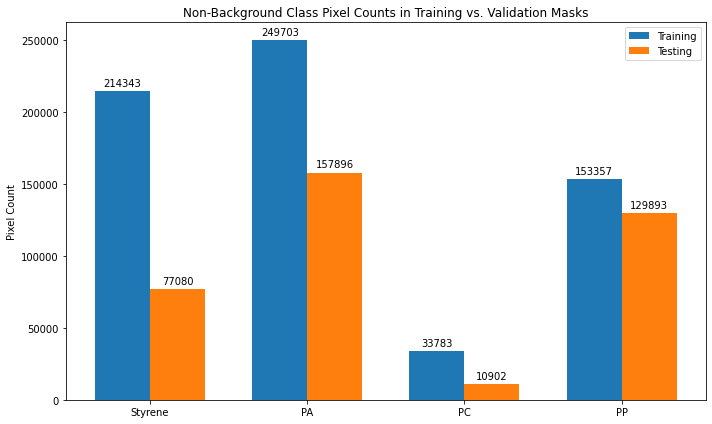

In [61]:
plot_non_background_statistics(Training_cubes_gt, Test_cubes_gt)

In [ ]:
# def extract_features_and_labels(hsi_input, mask_input, ignore_classes=[0]):
#     X = []
#     y = []
#     if isinstance(hsi_input, list) and isinstance(mask_input, list):
#         hsi_list = hsi_input
#         mask_list = mask_input
#     else:
#         hsi_list = [hsi_input]
#         mask_list = [mask_input]
#     for hsi, mask in zip(hsi_list, mask_list):
#         h, w, c = hsi.shape
#         for i in range(h):
#             for j in range(w):
#                 label = mask[i, j]
#                 if label not in ignore_classes:
#                     X.append(hsi[i, j, :].flatten())
#                     y.append(label)
#     return np.array(X), np.array(y)

In [ ]:
# train_X, train_y = extract_features_and_labels(Training_cubes, Training_cubes_gt, ignore_classes=[0])
# test_X, test_y = extract_features_and_labels(Test_cubes, Test_cubes_gt, ignore_classes=[0])

In [ ]:
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# import joblib

# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('knn', KNeighborsClassifier(n_neighbors=4, weights='distance', n_jobs=-1))
# ])

# pipeline.fit(train_X, train_y)

# # Save the model
# joblib.dump(pipeline, '/home/arbash44/coding/hsi/polymers/EBS_only/trained_models/knn.pkl')

# # Load the model (if needed)`
# pipeline = joblib.load('/home/arbash44/coding/hsi/polymers/EBS_only/trained_models/knn.pkl')



In [25]:
# y_pred = pipeline.predict(test_X)


In [26]:
# def evaluate_segmentation(ground_truth_masks, predicted_masks, num_classes):
#     eps = 1e-10

#     # --- Aggregate confusion matrix ---
#     confusion_matrix_sum = np.zeros((num_classes, num_classes), dtype=np.int64)

#     for gt_mask, pred_mask in zip(ground_truth_masks, predicted_masks):
#         cm = confusion_matrix(
#             gt_mask.flatten(),
#             pred_mask.flatten(),
#             labels=list(range(num_classes))
#         )
#         confusion_matrix_sum += cm

#     cm = confusion_matrix_sum
#     total = np.sum(cm)

#     # --- Core components ---
#     TP = np.diag(cm)
#     FP = np.sum(cm, axis=0) - TP
#     FN = np.sum(cm, axis=1) - TP
#     TN = total - (TP + FP + FN)

#     # --- Metrics ---
#     precision = TP / (TP + FP + eps)
#     recall = TP / (TP + FN + eps)
#     f1_score = 2 * precision * recall / (precision + recall + eps)

#     row_sum = np.sum(cm, axis=1)
#     col_sum = np.sum(cm, axis=0)

#     iou = TP / (row_sum + col_sum - TP + eps)
#     dice = 2 * TP / (row_sum + col_sum + eps)

#     # --- Accuracy ---
#     pixel_accuracy_per_class = recall  # same definition
#     OA = np.sum(TP) / (total + eps)
#     AA = np.mean(pixel_accuracy_per_class)

#     # --- Kappa (correct global version) ---
#     pe = np.sum(row_sum * col_sum) / ((total ** 2) + eps)
#     kappa = (OA - pe) / (1 - pe + eps)

#     return {
#         "confusion_matrix": cm,
#         "TP": TP,
#         "TN": TN,
#         "FP": FP,
#         "FN": FN,
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1_score,
#         "iou": iou,
#         "dice": dice,
#         "pixel_accuracy_per_class": pixel_accuracy_per_class,
#         "OA": OA,
#         "AA": AA,
#         "kappa": kappa
#     }

In [28]:
# # Adjust labels if needed (ensure consistency with your dataset)
# test_predictions2 = y_pred - 1
# test_y2 = test_y - 1

# # Evaluate segmentation metrics
# results = evaluate_segmentation(test_y2, test_predictions2, 4)

# print("Confusion Matrix:")
# print(results["confusion_matrix"])

# print("Pixel Accuracy (OA):", results["OA"])
# print("Average Accuracy (AA):", results["AA"])

# print("Precision:", results["precision"])
# print("Recall:", results["recall"])
# print("F1 Score:", results["f1_score"])

# print("IoU:", results["iou"])
# print("Dice Coefficient:", results["dice"])

# print("Kappa:", results["kappa"])

Confusion Matrix:
[[ 37515   5616   9090   5591]
 [ 10617 102654   2086   5029]
 [  1156    172  10390    786]
 [  3984   2316   1728 102256]]
Pixel Accuracy (OA): 0.8399560112430475
Average Accuracy (AA): 0.8149402673026835
Precision: [0.7042161  0.92683147 0.44603761 0.89964984]
Recall: [0.64891372 0.85270713 0.8309341  0.92720612]
F1 Score: [0.67543481 0.88822552 0.58047936 0.91322015]
IoU: [0.50992945 0.79892599 0.40892632 0.84029912]
Dice Coefficient: [0.67543481 0.88822552 0.58047936 0.91322015]
Kappa: 0.7636813149051404


In [23]:
# from copy import deepcopy
# # from EBS_only.ebs_dataset_loader import extract_features_and_labels

# def get_test_pred_maps(pipeline, test_cubes, test_cubes_gt=None, ignore_classes=[0]):
#     """
#     Runs the prediction pipeline on the test cubes and returns the predicted maps.
#     Args:
#         pipeline: The model inference pipeline/function to use.
#         test_cubes: List or array of test data cubes to predict on.
#         test_cubes_gt: List of ground truth masks corresponding to each test cube (for masking, or passing into feature extractor).
#         ignore_classes: List of classes to ignore during feature/label extraction.
#     Returns:
#         List of predicted class maps (np.ndarray) corresponding to each test cube.
#     """

#     pred_maps = []
#     i = 0
#     for cube, gt_mask in zip(test_cubes, test_cubes_gt):
#         print(i+1, len(test_cubes))
#         # 1. Extract features for this cube
#         features, valid_idx_or_y = extract_features_and_labels(
#             [cube], [gt_mask], ignore_classes=ignore_classes
#         )
#         # Only use features for prediction
#         # Features shape is (num_valid_pixels, num_bands)
#         pred_flat = pipeline.predict(features)
#         # Reconstruct full prediction mask with same spatial shape as HSI
#         mask_shape = cube.shape[:2]
#         # Prepare blank prediction map
#         pred_map = np.zeros(mask_shape, dtype=pred_flat.dtype)
#         # Get mask of valid pixels (not ignoring any of ignore_classes)
#         valid_mask = ~np.isin(gt_mask, ignore_classes)
#         # Flatten mask for indexing
#         pred_map[valid_mask] = pred_flat
#         pred_maps.append(deepcopy(pred_map))
#         i = i+1
#     return pred_maps

# # Usage assumes you have test gt masks:
# pred_maps = get_test_pred_maps(pipeline, Test_cubes, Test_cubes_gt)

1 5
2 5
3 5
4 5
5 5


In [24]:
# cube_semantic_majority = []
# cube_instance_majority = []
# for i, pred in enumerate(pred_maps):
#     print(i,len(pred_maps))
#     cube_semantic_majority.append(majority_vote_semantic_objects(pred, Test_cubes_semantic_masks[i])) 
#     cube_instance_majority.append(majority_vote_sam_instances(pred, Test_cubes_instance_masks[i]))


0 5
1 5
2 5
3 5
4 5


## Clean KNN Pixel, Semantic-Object, and SAM-Instance Workflow

Run the setup cells above first, up to the creation of `Training_cubes`, `Training_cubes_gt`, `Test_cubes`, `Test_cubes_gt`, `Test_cubes_semantic_masks`, and `Test_cubes_instance_masks`.

In [62]:
# 1) Helper functions: vector extraction, map reconstruction, and evaluation

from sklearn.metrics import confusion_matrix

CLASS_LABELS = [1, 2, 3, 4]
CLASS_NAMES = ['Styrene', 'PA', 'PC', 'PP']
BACKGROUND_LABEL = 0
EVALUATION_LABELS = [BACKGROUND_LABEL] + CLASS_LABELS


def extract_labeled_pixels(cubes, masks, ignore_labels=(BACKGROUND_LABEL,)):
    """Extract spectra and labels from non-background pixels."""
    X_parts = []
    y_parts = []
    valid_masks = []

    for cube, mask in zip(cubes, masks):
        cube = np.asarray(cube)
        mask = np.asarray(mask)

        if cube.shape[:2] != mask.shape:
            raise ValueError(f'Cube and mask shapes do not match: {cube.shape[:2]} vs {mask.shape}')

        valid_mask = ~np.isin(mask, ignore_labels)
        spectra = cube[valid_mask]
        labels = mask[valid_mask]

        finite_spectra = np.isfinite(spectra).all(axis=1)
        X_parts.append(spectra[finite_spectra])
        y_parts.append(labels[finite_spectra])

        final_valid_mask = np.zeros(mask.shape, dtype=bool)
        final_valid_mask[valid_mask] = finite_spectra
        valid_masks.append(final_valid_mask)

    return np.vstack(X_parts), np.concatenate(y_parts), valid_masks


def predict_maps(model, cubes, valid_masks):
    """Predict labels and place them back into full-size image maps."""
    pred_maps = []

    for cube, valid_mask in zip(cubes, valid_masks):
        cube = np.asarray(cube)
        spectra = cube[valid_mask]
        pred_labels = model.predict(spectra)

        pred_map = np.zeros(cube.shape[:2], dtype=pred_labels.dtype)
        pred_map[valid_mask] = pred_labels
        pred_maps.append(pred_map)

    return pred_maps


def evaluate_maps(gt_maps, pred_maps, labels=EVALUATION_LABELS, class_labels=CLASS_LABELS, ignore_labels=(BACKGROUND_LABEL,)):
    """Evaluate maps on non-background GT pixels while counting background predictions as errors."""
    y_true_parts = []
    y_pred_parts = []

    for gt_map, pred_map in zip(gt_maps, pred_maps):
        gt_map = np.asarray(gt_map)
        pred_map = np.asarray(pred_map)

        if gt_map.shape != pred_map.shape:
            raise ValueError(f'GT and prediction shapes do not match: {gt_map.shape} vs {pred_map.shape}')

        eval_mask = ~np.isin(gt_map, ignore_labels)
        y_true_parts.append(gt_map[eval_mask])
        y_pred_parts.append(pred_map[eval_mask])

    y_true = np.concatenate(y_true_parts)
    y_pred = np.concatenate(y_pred_parts)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    eps = 1e-10
    label_to_index = {label: index for index, label in enumerate(labels)}
    class_indices = [label_to_index[label] for label in class_labels]

    tp = np.diag(cm)[class_indices]
    fp = cm[:, class_indices].sum(axis=0) - tp
    fn = cm[class_indices, :].sum(axis=1) - tp

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    oa = tp.sum() / (cm.sum() + eps)
    aa = recall.mean()

    return {
        'labels': labels,
        'confusion_matrix': cm,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'iou': iou,
        'OA': oa,
        'AA': aa,
    }


def print_evaluation(title, results):
    print(title)
    print('Labels:', results['labels'])
    print('Confusion Matrix:')
    print(results['confusion_matrix'])
    print('OA:', results['OA'])
    print('AA:', results['AA'])
    print('Precision:', dict(zip(CLASS_NAMES, results['precision'])))
    print('Recall:', dict(zip(CLASS_NAMES, results['recall'])))
    print('F1:', dict(zip(CLASS_NAMES, results['f1_score'])))
    print('IoU:', dict(zip(CLASS_NAMES, results['iou'])))

In [40]:
# 2) Extract train/test vectors and labels, ignoring background label 0

train_X, train_y, train_valid_masks = extract_labeled_pixels(
    Training_cubes,
    Training_cubes_gt,
    ignore_labels=(BACKGROUND_LABEL,),
)

test_X, test_y, test_valid_masks = extract_labeled_pixels(
    Test_cubes,
    Test_cubes_gt,
    ignore_labels=(BACKGROUND_LABEL,),
)

print('train_X:', train_X.shape, 'train_y:', train_y.shape)
print('test_X:', test_X.shape, 'test_y:', test_y.shape)
print('Train labels:', dict(zip(*np.unique(train_y, return_counts=True))))
print('Test labels:', dict(zip(*np.unique(test_y, return_counts=True))))

train_X: (651186, 143) train_y: (651186,)
test_X: (375771, 143) test_y: (375771,)
Train labels: {1: 214343, 2: 249703, 3: 33783, 4: 153357}
Test labels: {1: 77080, 2: 157896, 3: 10902, 4: 129893}


In [63]:
# 3) Train the KNN model on spectral vectors

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=4, weights='distance', n_jobs=-1)),
])

knn_model.fit(train_X, train_y)

model_path = DATASET_ROOT.parent / 'trained_models' / 'knn.pkl'
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(knn_model, model_path)

#knn_model = joblib.load(model_path)

print(f'Saved model to: {model_path}')


Saved model to: /home/arbash44/coding/hsi/polymers/EBS_only/trained_models/knn.pkl


In [64]:
# 4) Pixel-wise prediction and pixel-wise evaluation

pixel_pred_maps = predict_maps(knn_model, Test_cubes, test_valid_masks)
pixel_results = evaluate_maps(Test_cubes_gt, pixel_pred_maps)

print_evaluation('Pixel-wise KNN evaluation', pixel_results)

Pixel-wise KNN evaluation
Labels: [0, 1, 2, 3, 4]
Confusion Matrix:
[[     0      0      0      0      0]
 [     0  45227  11838  10305   9710]
 [     0   4975 145876    311   6734]
 [     0   1125    263   8986    528]
 [     0   5267   3256   1373 119997]]
OA: 0.851811342546391
AA: 0.8146736528001202
Precision: {'Styrene': 0.7991483196098512, 'PA': 0.9047527491270393, 'PC': 0.42841477949940204, 'PP': 0.8760887500091256}
Recall: {'Styrene': 0.5867540217955364, 'PA': 0.9238739423417941, 'PC': 0.8242524307466444, 'PP': 0.923814216316506}
F1: {'Styrene': 0.6766760925346226, 'PA': 0.9142133744788006, 'PC': 0.5637920757463121, 'PP': 0.8993187489663801}
IoU: {'Styrene': 0.5113457776973775, 'PA': 0.8419825342129713, 'PC': 0.3925560263859142, 'PP': 0.817056480441221}


Sample index: 1
Ground truth labels: (array([0, 2]), array([586315, 126645]))
Prediction labels: (array([0, 1, 2, 3, 4]), array([586315,   1823, 123904,    139,    779]))


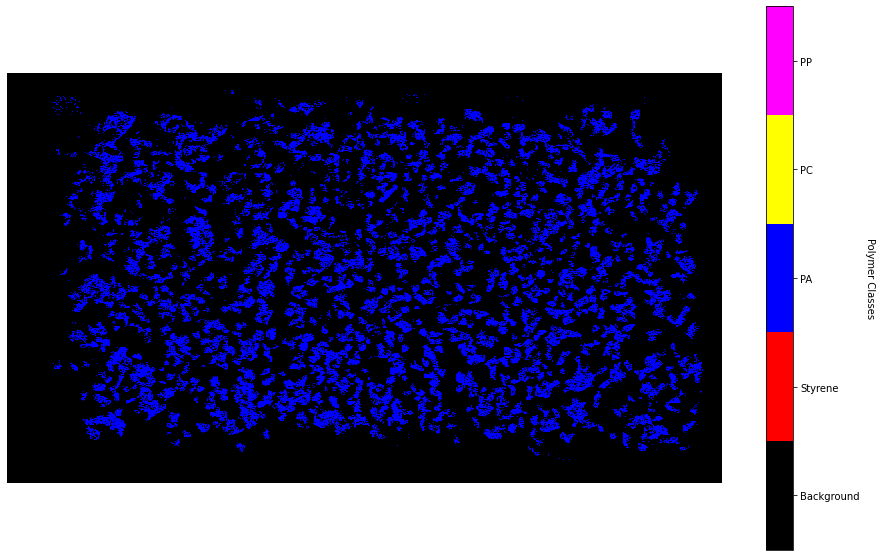

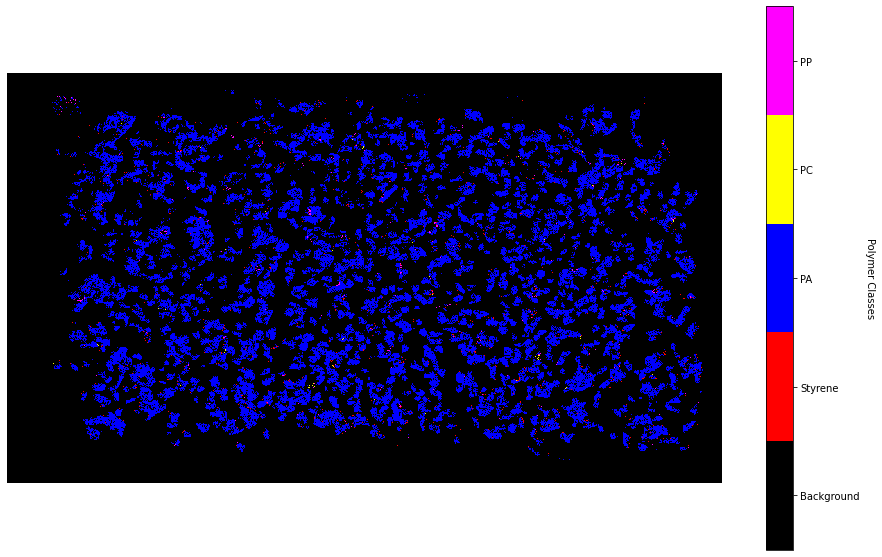

In [65]:
# 5) Optional: visualize one pixel-wise prediction map

sample_idx = 1
print('Sample index:', sample_idx)
print('Ground truth labels:', np.unique(Test_cubes_gt[sample_idx], return_counts=True))
print('Prediction labels:', np.unique(pixel_pred_maps[sample_idx], return_counts=True))

visualize_mask(Test_cubes_gt[sample_idx])
visualize_mask(pixel_pred_maps[sample_idx])

Semantic-object majority voting evaluation
Labels: [0, 1, 2, 3, 4]
Confusion Matrix:
[[     0      0      0      0      0]
 [     0 124638   8057  12466  18125]
 [     0   3191 205780      0   8536]
 [     0   2437   1945 124664    696]
 [     0   1967   1288    590 262572]]
OA: 0.9236786828529946
AA: 0.9139560043020818
Precision: {'Styrene': 0.9425635053277164, 'PA': 0.9479891279310818, 'PC': 0.9051989544002318, 'PP': 0.9056424159018239}
Recall: {'Styrene': 0.7633110003307076, 'PA': 0.946084493832382, 'PC': 0.9608607852507276, 'PP': 0.9855677377945097}
F1: {'Styrene': 0.8435193675715843, 'PA': 0.9470358532050039, 'PC': 0.9321997143019891, 'PP': 0.9439161959863686}
IoU: {'Styrene': 0.7293847765403991, 'PA': 0.8993999047190301, 'PC': 0.873009425902323, 'PP': 0.8937891031881647}


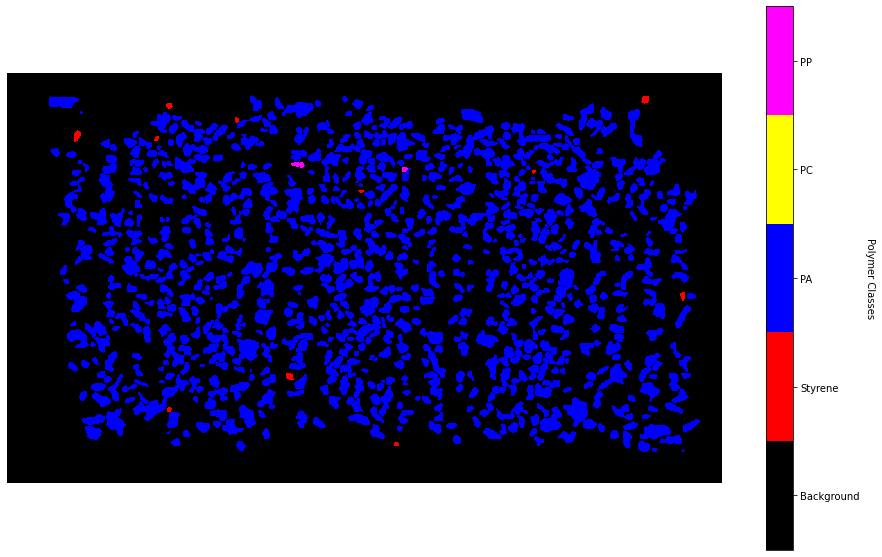

In [66]:
# 6) Semantic-segmentation majority voting on pixel-wise prediction maps

semantic_majority_maps = [
    majority_vote_semantic_objects(pred_map, semantic_mask, ignore_labels=(BACKGROUND_LABEL,))
    for pred_map, semantic_mask in zip(pixel_pred_maps, Test_cubes_semantic_masks)
]

gt_semantic_majority_maps = [
    majority_vote_semantic_objects(pred_map, semantic_mask, ignore_labels=(BACKGROUND_LABEL,))
    for pred_map, semantic_mask in zip(Test_cubes_gt, Test_cubes_semantic_masks)
]

semantic_results = evaluate_maps(gt_semantic_majority_maps, semantic_majority_maps)
print_evaluation('Semantic-object majority voting evaluation', semantic_results)

visualize_mask(semantic_majority_maps[sample_idx])

SAM-instance majority voting evaluation
Labels: [0, 1, 2, 3, 4]
Confusion Matrix:
[[     0      0      0      0      0]
 [     0 122842  11794  14549  15021]
 [     0   4045 205868      2   5271]
 [     0   5047   2580 109795   1411]
 [     0   2931   2038    643 250820]]
OA: 0.9134282197077611
AA: 0.9017133926589661
Precision: {'Styrene': 0.9108515923330732, 'PA': 0.926165197048767, 'PC': 0.8784373024826178, 'PP': 0.9203626849843862}
Recall: {'Styrene': 0.7480969026710348, 'PA': 0.9566979264450286, 'PC': 0.9239436856765368, 'PP': 0.9781150558432642}
F1: {'Styrene': 0.8214905490174248, 'PA': 0.9411840005352011, 'PC': 0.9006160231144706, 'PP': 0.9483604464908669}
IoU: {'Styrene': 0.6970589403560137, 'PA': 0.8889023221271337, 'PC': 0.8192006088325481, 'PP': 0.9017922951084901}


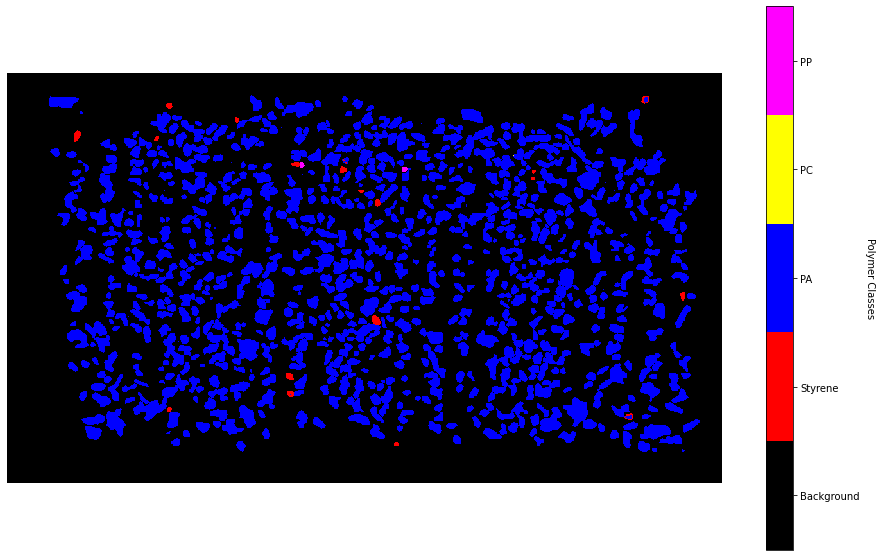

In [67]:
# 7) SAM-instance majority voting on pixel-wise prediction maps

sam_instance_majority_maps = [
    majority_vote_sam_instances(
        pred_map,
        instances,
        ignore_labels=(BACKGROUND_LABEL,),
        overwrite_overlaps=False,
    )
    for pred_map, instances in zip(pixel_pred_maps, Test_cubes_instance_masks)
]

gt_sam_instance_majority_maps = [
    majority_vote_sam_instances(
        pred_map,
        instances,
        ignore_labels=(BACKGROUND_LABEL,),
        overwrite_overlaps=False,
    )
    for pred_map, instances in zip(Test_cubes_gt, Test_cubes_instance_masks)
]


sam_instance_results = evaluate_maps(gt_sam_instance_majority_maps, sam_instance_majority_maps)
print_evaluation('SAM-instance majority voting evaluation', sam_instance_results)

visualize_mask(sam_instance_majority_maps[sample_idx])

In [70]:
# 8) Quick comparison of the three evaluation stages

summary = {
    'Pixel-wise KNN': pixel_results,
    'Semantic majority': semantic_results,
    'SAM-instance majority': sam_instance_results,
}

for name, result in summary.items():
    # Handle the case where result['f1_score'] is a numpy array
    f1_score = result['f1_score']
    if hasattr(f1_score, "item") and f1_score.shape == ():
        f1_score = f1_score.item()  # scalar numpy array
    elif hasattr(f1_score, "__len__") and not isinstance(f1_score, str):
        try:
            # Try to average across all classes if it's a vector
            f1_score = float(np.mean(f1_score))
        except Exception:
            # fallback to string representation if something goes wrong
            pass

    print(f"{name}: OA={result['OA']:.4f}, AA={result['AA']:.4f}, f1_score={f1_score:.4f}")

Pixel-wise KNN: OA=0.8518, AA=0.8147, f1_score=0.7635
Semantic majority: OA=0.9237, AA=0.9140, f1_score=0.9167
SAM-instance majority: OA=0.9134, AA=0.9017, f1_score=0.9029


Sample index: -1
Ground truth labels: (array([0, 1, 2, 3, 4]), array([767232,  37113,  31251,   2573,  38631]))
Prediction labels: (array([0, 1, 2, 3, 4]), array([767232,  27577,  28293,   5044,  48654]))


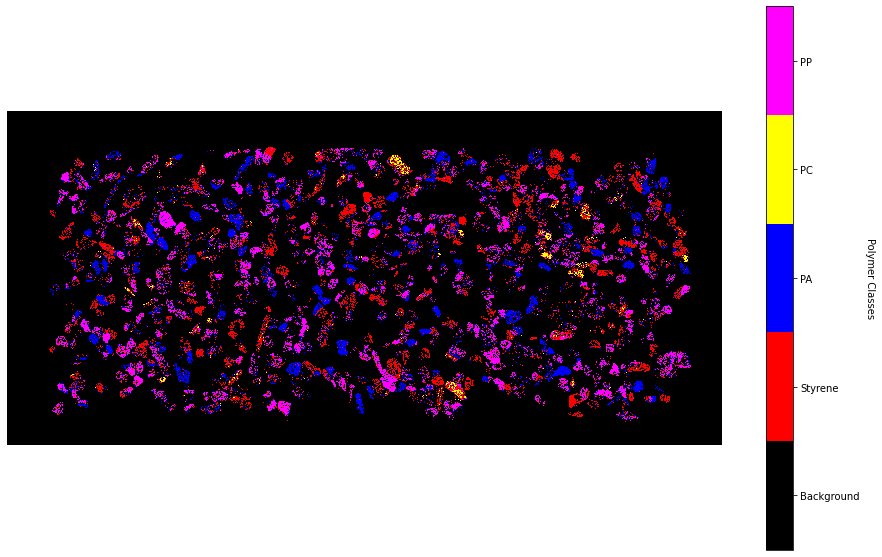

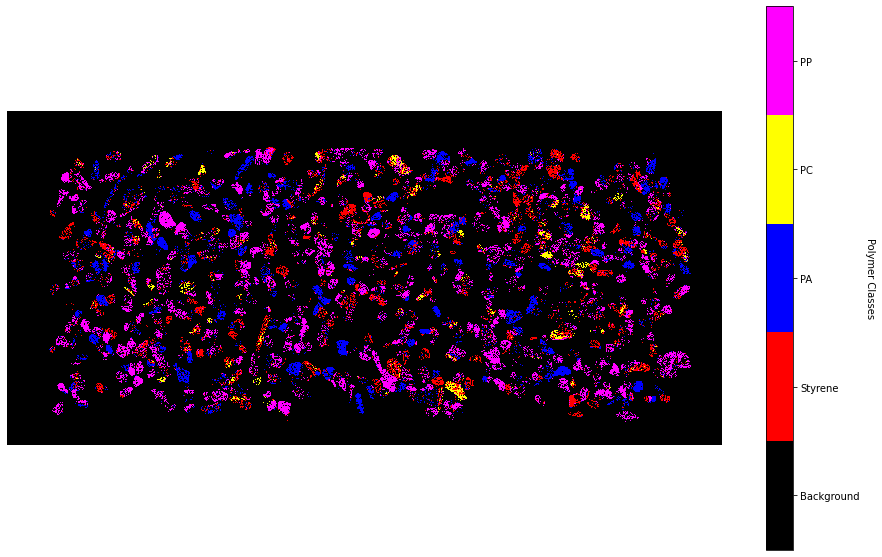

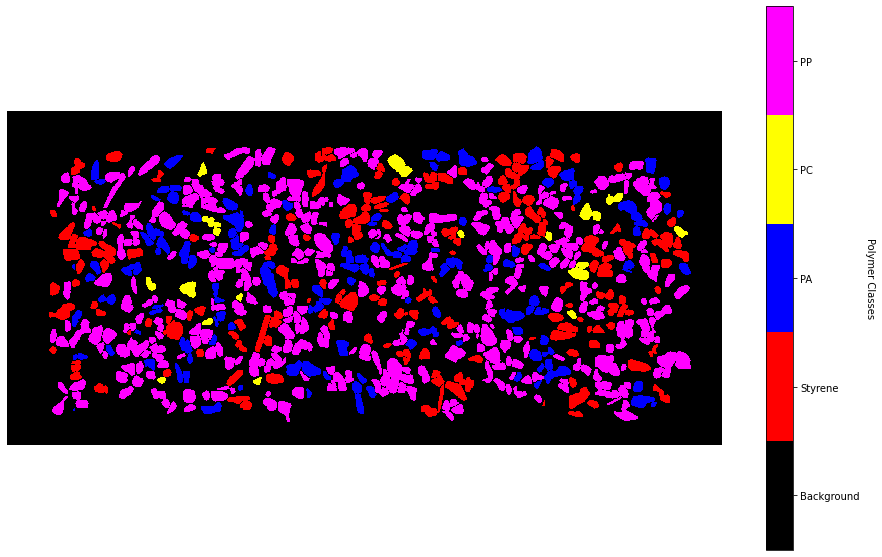

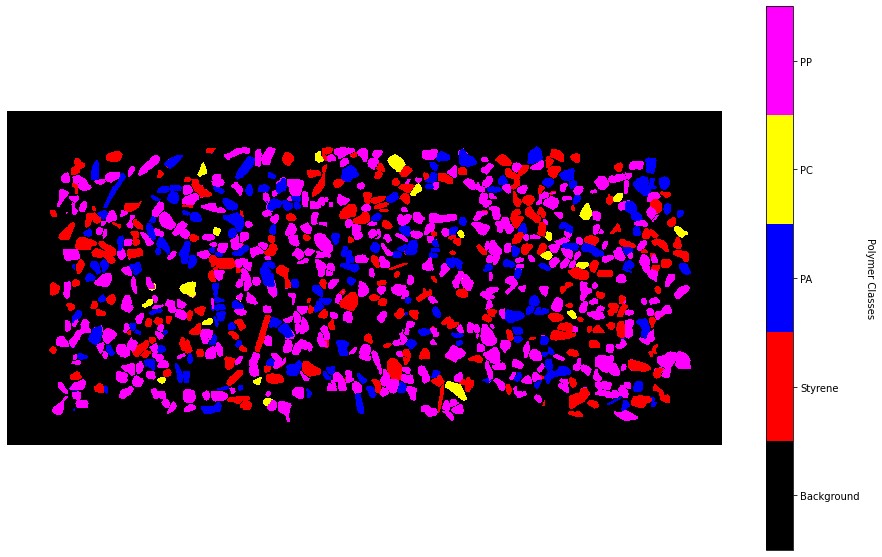

In [69]:
# 5) Optional: visualize one pixel-wise prediction map

sample_idx = -1
print('Sample index:', sample_idx)
print('Ground truth labels:', np.unique(Test_cubes_gt[sample_idx], return_counts=True))
print('Prediction labels:', np.unique(pixel_pred_maps[sample_idx], return_counts=True))

visualize_mask(Test_cubes_gt[sample_idx])
visualize_mask(pixel_pred_maps[sample_idx])
visualize_mask(semantic_majority_maps[sample_idx])
visualize_mask(sam_instance_majority_maps[sample_idx])